In [1]:
import pandas as pd

df = pd.read_csv("/users/framunno/data/ionosphere/l1_to_map_matched_even_minutes.csv")

In [2]:
len(df)

247563

In [3]:
df_v2 = pd.read_csv("/users/framunno/data/ionosphere/l1_to_map_matched_even_minutes_test_v3_interpolated.csv")

In [4]:
len(df_v2)

496235

In [5]:
df_v2.head()

,time,proton_vx_gsm,bx_gsm,by_gsm,bz_gsm,speed_kms,delay_min,earth_time,time_map,dt_diff,filename
0,2024-01-06 12:24:00+00:00,-473.5,2.69,0.27,-0.01,473.5,52.798310,2024-01-06 13:16:47.898627+00:00,2024-01-06 13:16:00,-1 days +23:59:12.101373,map_2024_1_6_13_16_0.npy
1,2024-01-06 06:03:00+00:00,-476.4,1.25,-2.67,0.09,476.4,52.476910,2024-01-06 06:55:28.614610+00:00,2024-01-06 06:56:00,0 days 00:00:31.385390,map_2024_1_6_6_56_0.npy
2,2024-01-03 10:52:00+00:00,-420.8,5.23,3.28,-0.36,420.8,59.410646,2024-01-03 11:51:24.638783+00:00,2024-01-03 11:52:00,0 days 00:00:35.361217,map_2024_1_3_11_52_0.npy
3,2024-01-01 10:31:00+00:00,-317.7,1.51,-8.15,-1.60,317.7,78.690589,2024-01-01 11:49:41.435316+00:00,2024-01-01 11:50:00,0 days 00:00:18.564684,map_2024_1_1_11_50_0.npy
4,2024-01-07 02:09:00+00:00,-485.1,0.91,-2.74,0.52,485.1,51.535766,2024-01-07 03:00:32.145949+00:00,2024-01-07 03:00:00,-1 days +23:59:27.854051,map_2024_1_7_3_0_0.npy


In [5]:
df_v2 = df_v2.sort_values('earth_time').reset_index(drop=True)

In [6]:
import numpy as np

count = np.unique(df_v2['time_map'], return_counts=True)


In [7]:
len(count[0])

240634

In [ ]:
print(f"Original rows: {len(df_v2)}")
print(f"Unique time_map values: {len(df_v2['time_map'].unique())}")

# Convert dt_diff to timedelta if it's not already
df_v2['dt_diff'] = pd.to_timedelta(df_v2['dt_diff'])

# Calculate absolute dt_diff in seconds for sorting
df_v2['dt_diff_abs_seconds'] = df_v2['dt_diff'].abs().dt.total_seconds()

# Keep only the row with minimum absolute dt_diff for each time_map
df_filtered = df_v2.loc[df_v2.groupby('time_map')['dt_diff_abs_seconds'].idxmin()]

# Drop the helper column
df_filtered = df_filtered.drop('dt_diff_abs_seconds', axis=1)

# Reset index
df_filtered = df_filtered.reset_index(drop=True)

print(f"\nFiltered rows: {len(df_filtered)}")
print(f"Unique time_map values: {len(df_filtered['time_map'].unique())}")

# Verify no duplicates
assert len(df_filtered) == len(df_filtered['time_map'].unique()), "Still have duplicates!"

# Save the filtered dataset
output_file = "/users/framunno/data/ionosphere/l1_to_map_matched_even_minutes_test_v3_interpolated_deduplicated.csv"
df_filtered.to_csv(output_file, index=False)
print(f"\nSaved to: {output_file}")

Original rows: 496235
Unique time_map values: 240634

Filtered rows: 240634
Unique time_map values: 240634

Saved to: /users/framunno/data/ionosphere/l1_to_map_matched_even_minutes_test_v3_interpolated_deduplicated.csv


In [10]:
df_v2 = pd.read_csv("/users/framunno/data/ionosphere/l1_to_map_matched_even_minutes_test_v3_deduplicated.csv")

In [11]:
df_v2.head()

,time,proton_vx_gsm,bx_gsm,by_gsm,bz_gsm,speed_kms,delay_min,earth_time,time_map,dt_diff,filename
0,2024-01-01 00:11:00+00:00,-426.0,3.85,-3.06,-2.14,426.0,58.685446,2024-01-01 01:09:41.126761+00:00,2024-01-01 01:10:00,0 days 00:00:18.873239,map_2024_1_1_1_10_0.npy
1,2024-01-01 00:04:00+00:00,-364.4,3.23,-2.09,-3.22,364.4,68.605928,2024-01-01 01:12:36.355653+00:00,2024-01-01 01:12:00,-1 days +23:59:23.644347,map_2024_1_1_1_12_0.npy
2,2024-01-01 00:10:00+00:00,-383.2,3.72,-3.44,-1.73,383.2,65.240083,2024-01-01 01:15:14.405010+00:00,2024-01-01 01:16:00,0 days 00:00:45.594990,map_2024_1_1_1_16_0.npy
3,2024-01-01 00:12:00+00:00,-366.5,4.15,-2.59,-2.24,366.5,68.212824,2024-01-01 01:20:12.769441+00:00,2024-01-01 01:20:00,-1 days +23:59:47.230559,map_2024_1_1_1_20_0.npy
4,2024-01-01 00:00:00+00:00,-306.2,3.51,-3.62,-1.44,306.2,81.645983,2024-01-01 01:21:38.758981+00:00,2024-01-01 01:22:00,0 days 00:00:21.241019,map_2024_1_1_1_22_0.npy


In [12]:
df_v2['time_map'] = pd.to_datetime(df_v2['time_map'])
df_v2 = df_v2.sort_values('time_map').reset_index(drop=True)

In [13]:
dt = df_v2['time_map'].diff()

dt == pd.Timedelta(minutes=2)

is_continuous = dt == pd.Timedelta(minutes=2)

block_id = (~is_continuous).cumsum()
df_v2['block_id'] = block_id

block_sizes = df_v2.groupby('block_id').size()
block_sizes >= 31
num_1h_sequences = (block_sizes >= 31).sum()

df_v2['time_map'] = pd.to_datetime(df_v2['time_map'])
df_v2 = df_v2.sort_values('time_map').reset_index(drop=True)

dt = df_v2['time_map'].diff()
block_id = (dt != pd.Timedelta(minutes=2)).cumsum()

num_1h_sequences = (df_v2.groupby(block_id).size() >= 31).sum()
print(f"Time range: {df_v2['time_map'].min()} to {df_v2['time_map'].max()}")

Time range: 2024-01-01 01:10:00 to 2024-12-31 22:28:00


In [14]:
num_1h_sequences


np.int64(2081)

In [25]:
start = pd.Timestamp("2024-01-01 01:12:00")
end   = pd.Timestamp("2024-12-31 22:28:00")

total_seconds = (end - start).total_seconds()
total_possible = int((total_seconds - 3600) // 120 + 1)

In [27]:
total_possible

263409

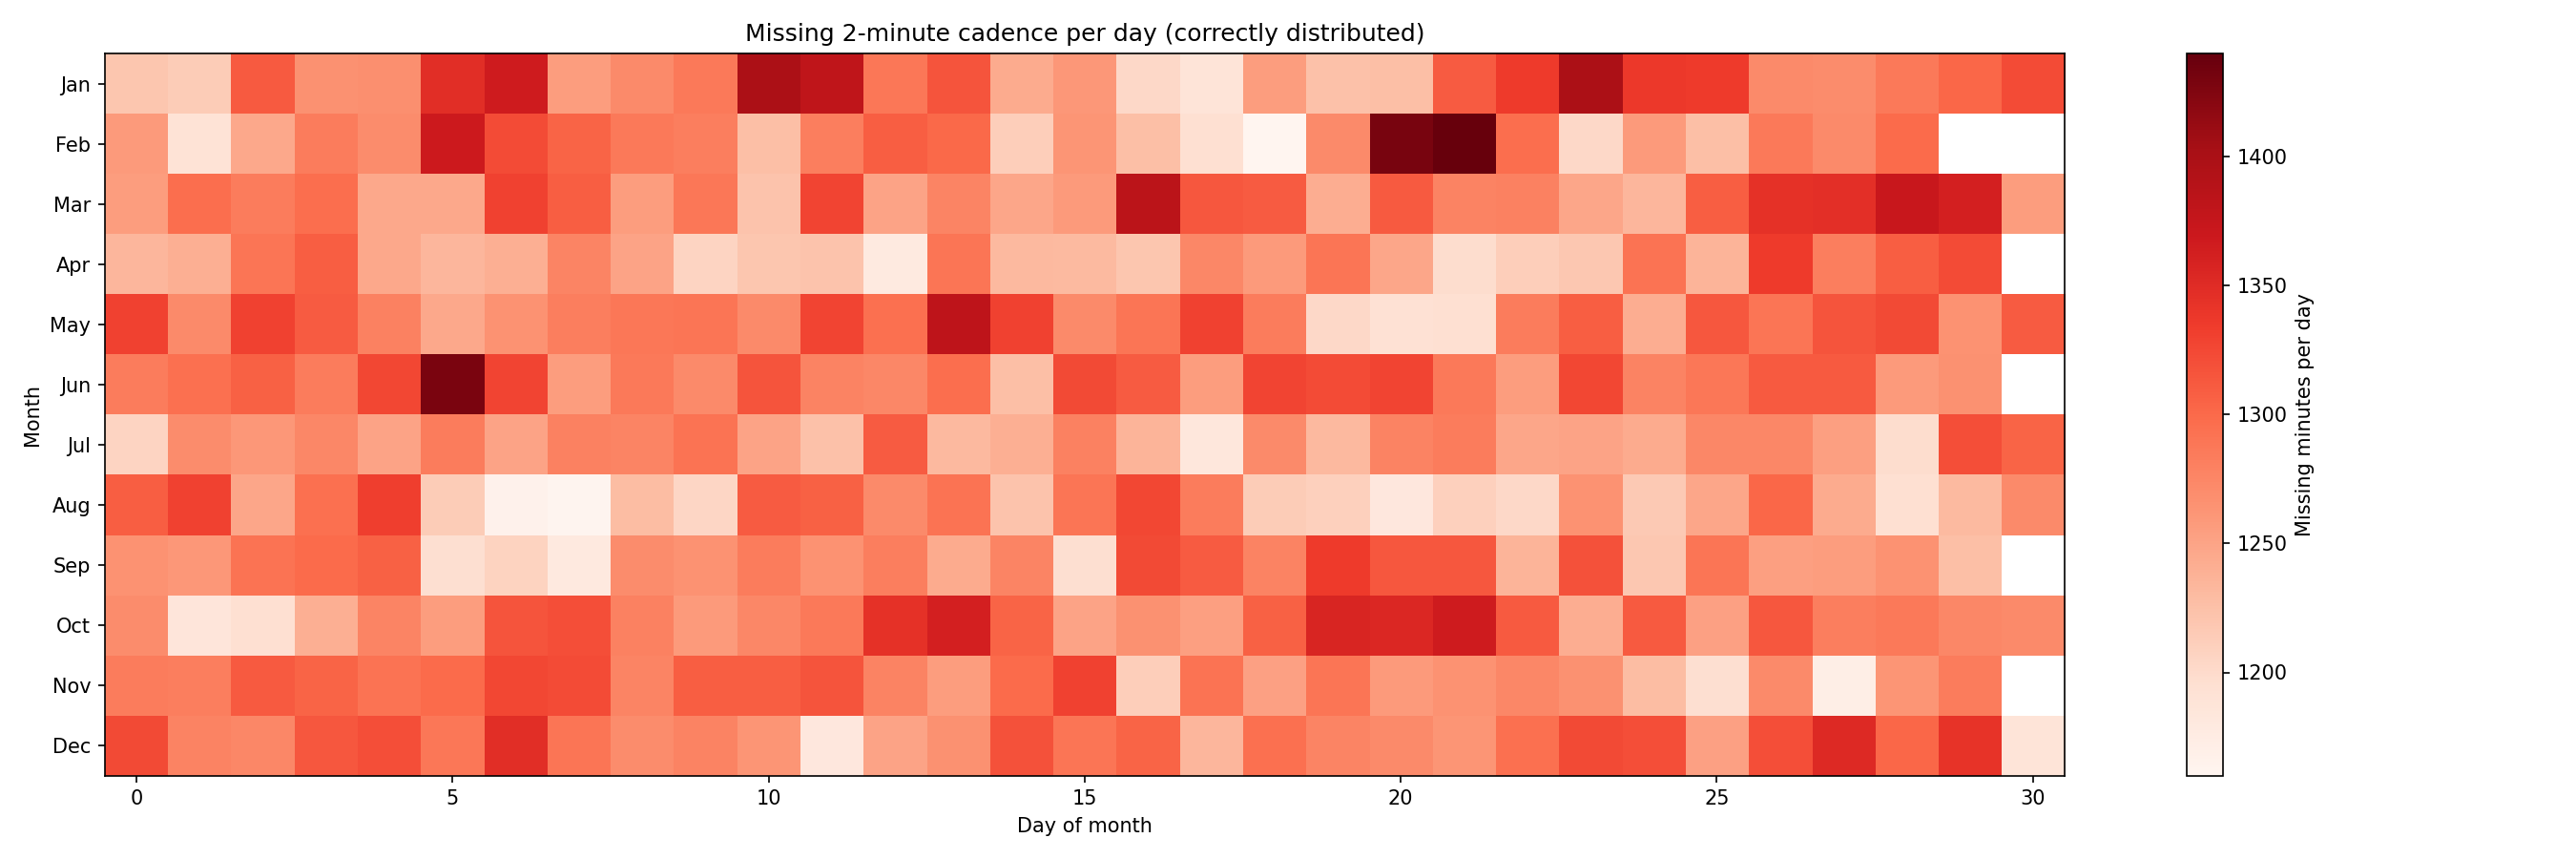

In [78]:
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from PIL import Image
from collections import defaultdict

# --------------------------------------------------
# 1. Load data
# --------------------------------------------------
df_v2 = pd.read_csv(
    "/users/framunno/data/ionosphere/l1_to_map_matched_even_minutes_test_v2_deduplicated.csv"
)

df_v2['time_map'] = pd.to_datetime(df_v2['time_map'], utc=True).dt.tz_convert(None)
df_v2 = df_v2.sort_values('time_map').reset_index(drop=True)

# --------------------------------------------------
# 2. Detect gaps relative to 2-minute cadence
# --------------------------------------------------
expected_dt = pd.Timedelta(minutes=2)

dt = df_v2['time_map'].diff()
gap_mask = dt > expected_dt

gap_starts = df_v2.loc[gap_mask, 'time_map'].shift(1)
gap_ends   = df_v2.loc[gap_mask, 'time_map']

# --------------------------------------------------
# 3. Distribute missing minutes ACROSS DAYS (CORRECT)
# --------------------------------------------------
missing_minutes_per_day = defaultdict(float)

for start, end in zip(gap_starts, gap_ends):
    if pd.isna(start) or pd.isna(end):
        continue

    # actual missing interval (exclude expected 2 minutes)
    gap_start = start + expected_dt
    gap_end   = end

    current = gap_start

    while current < gap_end:
        day_end = pd.Timestamp(
            year=current.year,
            month=current.month,
            day=current.day
        ) + pd.Timedelta(days=1)

        interval_end = min(day_end, gap_end)

        missing_minutes = (interval_end - current).total_seconds() / 60
        missing_minutes_per_day[current.date()] += missing_minutes

        current = interval_end

# Convert to Series
missing_minutes_per_day = pd.Series(missing_minutes_per_day)

# --------------------------------------------------
# 4. Build full daily index
# --------------------------------------------------
all_days = pd.date_range(
    df_v2['time_map'].dt.date.min(),
    df_v2['time_map'].dt.date.max(),
    freq='D'
)

missing_minutes_per_day = (
    missing_minutes_per_day
    .reindex(all_days.date, fill_value=0)
)

# Sanity check: no day > 1440 minutes
missing_minutes_per_day = missing_minutes_per_day.clip(upper=1440)

# --------------------------------------------------
# 5. Build month × day-of-month matrix
# --------------------------------------------------
calendar_df = (
    missing_minutes_per_day
    .rename_axis('date')
    .reset_index(name='missing_minutes')
)

calendar_df['month'] = calendar_df['date'].apply(lambda d: d.month)
calendar_df['day']   = calendar_df['date'].apply(lambda d: d.day)

heatmap_data = calendar_df.pivot(
    index='month',
    columns='day',
    values='missing_minutes'
)

# --------------------------------------------------
# 6. Plot heatmap
# --------------------------------------------------
plt.figure(figsize=(18, 6))
plt.imshow(heatmap_data, aspect='auto', cmap='Reds')

plt.colorbar(label='Missing minutes per day')

plt.xlabel('Day of month')
plt.ylabel('Month')
plt.yticks(
    ticks=np.arange(12),
    labels=['Jan','Feb','Mar','Apr','May','Jun',
            'Jul','Aug','Sep','Oct','Nov','Dec']
)

plt.title('Missing 2-minute cadence per day (correctly distributed)')
plt.tight_layout()

output_path = "/users/framunno/visual_res/missing_minutes_per_day_heatmap.png"
plt.savefig(output_path, dpi=150)
plt.close()

Image.open(output_path)



In [80]:
import pandas as pd
import numpy as np

# Load the deduplicated data
df = pd.read_csv("/users/framunno/data/ionosphere/l1_to_map_matched_even_minutes_test_v2_deduplicated.csv")
df['time_map'] = pd.to_datetime(df['time_map'])
df = df.sort_values('time_map').reset_index(drop=True)

print("=" * 80)
print("GAP ANALYSIS")
print("=" * 80)

# Calculate time differences
dt = df['time_map'].diff()

# Count gap types
gaps = dt[dt != pd.Timedelta(minutes=2)]
print(f"\nTotal samples: {len(df):,}")
print(f"Total gaps (discontinuities): {len(gaps):,}")
print(f"Continuous transitions: {(dt == pd.Timedelta(minutes=2)).sum():,}")

# Gap size distribution
print("\n" + "-" * 80)
print("GAP SIZE DISTRIBUTION")
print("-" * 80)
gap_minutes = gaps.dt.total_seconds() / 60
print(gap_minutes.describe())

# Show gap histogram
print("\nGap sizes (in 2-min intervals):")
gap_intervals = (gap_minutes / 2).dropna().astype(int)  # FIX: Drop NaN before converting
print(gap_intervals.value_counts().sort_index().head(20))

# Analyze continuous blocks
block_id = (dt != pd.Timedelta(minutes=2)).cumsum()
block_sizes = df.groupby(block_id).size()

print("\n" + "-" * 80)
print("CONTINUOUS BLOCK STATISTICS")
print("-" * 80)
print(f"Total blocks: {len(block_sizes):,}")
print(f"Blocks ≥ 31 samples (1 hour): {(block_sizes >= 31).sum():,}")
print(f"Blocks ≥ 61 samples (2 hours): {(block_sizes >= 61).sum():,}")
print(f"Blocks ≥ 181 samples (6 hours): {(block_sizes >= 181).sum():,}")

print("\nBlock size distribution:")
print(block_sizes.describe())

print(f"\nLargest continuous block: {block_sizes.max()} samples = {block_sizes.max() * 2} minutes = {block_sizes.max() * 2 / 60:.1f} hours")

# Time coverage
time_range = (df['time_map'].max() - df['time_map'].min()).total_seconds() / 60
print(f"\n" + "-" * 80)
print(f"TIME COVERAGE")
print(f"-" * 80)
print(f"Time range: {df['time_map'].min()} to {df['time_map'].max()}")
print(f"Total span: {time_range / 60 / 24:.1f} days")
print(f"Expected even-minute slots: {int(time_range / 2):,}")
print(f"Actual samples: {len(df):,}")
print(f"Coverage: {len(df) / (time_range / 2) * 100:.2f}%")

GAP ANALYSIS

Total samples: 214,409
Total gaps (discontinuities): 29,838
Continuous transitions: 184,571

--------------------------------------------------------------------------------
GAP SIZE DISTRIBUTION
--------------------------------------------------------------------------------
count    29837.000000
mean         5.286523
std         22.252680
min          4.000000
25%          4.000000
50%          4.000000
75%          4.000000
max       2878.000000
Name: time_map, dtype: float64

Gap sizes (in 2-min intervals):
time_map
2     26681
3      2090
4       432
5       177
6        76
7        56
8        30
9        22
10       11
11       14
12        6
13       13
14        5
15        2
16        1
18        4
19        7
20        5
21        2
22        4
Name: count, dtype: int64

--------------------------------------------------------------------------------
CONTINUOUS BLOCK STATISTICS
--------------------------------------------------------------------------------
Tot

In [1]:
import pandas as pd
import os
from datetime import datetime
from tqdm import tqdm

MAP_DIR = '/users/framunno/data/ionosphere/ionosphere_data/pickled_maps/'

def extract_datetime_from_filename(filename):
    """
    Extract datetime from ionosphere map filename.
    Format: map_2024_9_1_13_48_0.npy or _2024_9_1_13_48_0.npy
    Returns: datetime object or None if parsing fails
    """
    parts = filename.replace('.npy', '').split('_')
    try:
        # Skip 'map' or empty prefix
        if parts[0] == 'map' or parts[0] == '':
            parts = parts[1:]

        year, month, day, hour, minute, second = parts[0:6]
        return datetime(int(year), int(month), int(day),
                        int(hour), int(minute), int(second))
    except:
        return None


print("=" * 80)
print("MAP FILES GAP ANALYSIS")
print("=" * 80)

# Scan all .npy files
print("\n[1/2] Scanning map files...")
all_files = [f for f in os.listdir(MAP_DIR) if f.endswith('.npy')]
print(f"Found {len(all_files):,} .npy files")

# Parse filenames and filter for even minutes
print("\n[2/2] Parsing filenames and filtering for even minutes...")
map_data = []
parse_failures = 0

for filename in tqdm(all_files, desc="Parsing"):
    dt = extract_datetime_from_filename(filename)
    if dt is not None and dt.minute % 2 == 0:  # Only even minutes
        map_data.append({
            'filename': filename,
            'map_time': pd.Timestamp(dt)
        })
    elif dt is None:
        parse_failures += 1

map_df = pd.DataFrame(map_data)
map_df = map_df.sort_values('map_time').reset_index(drop=True)

print(f"\nTotal .npy files: {len(all_files):,}")
print(f"Parse failures: {parse_failures:,}")
print(f"Map files with even minutes: {len(map_df):,}")
print(f"Time range: {map_df['map_time'].min()} to {map_df['map_time'].max()}")

# Gap analysis
print("\n" + "=" * 80)
print("GAP ANALYSIS")
print("=" * 80)

# Calculate time differences
dt = map_df['map_time'].diff()

# Count gap types
gaps = dt[dt != pd.Timedelta(minutes=2)]
print(f"\nTotal map files (even min): {len(map_df):,}")
print(f"Total gaps (discontinuities): {len(gaps):,}")
print(f"Continuous transitions: {(dt == pd.Timedelta(minutes=2)).sum():,}")

# Gap size distribution
print("\n" + "-" * 80)
print("GAP SIZE DISTRIBUTION")
print("-" * 80)
gap_minutes = gaps.dt.total_seconds() / 60
print(gap_minutes.describe())

print("\nGap sizes (in 2-min intervals):")
gap_intervals = (gap_minutes / 2).dropna().astype(int)
print(gap_intervals.value_counts().sort_index().head(20))

# Analyze continuous blocks
block_id = (dt != pd.Timedelta(minutes=2)).cumsum()
block_sizes = map_df.groupby(block_id).size()

print("\n" + "-" * 80)
print("CONTINUOUS BLOCK STATISTICS")
print("-" * 80)
print(f"Total blocks: {len(block_sizes):,}")
print(f"Blocks ≥ 31 samples (1 hour): {(block_sizes >= 31).sum():,}")
print(f"Blocks ≥ 61 samples (2 hours): {(block_sizes >= 61).sum():,}")
print(f"Blocks ≥ 181 samples (6 hours): {(block_sizes >= 181).sum():,}")

print("\nBlock size distribution:")
print(block_sizes.describe())

print(f"\nLargest continuous block: {block_sizes.max()} samples = {block_sizes.max() * 2} minutes = {block_sizes.max() * 2 / 60:.1f} hours")

# Time coverage
time_range = (map_df['map_time'].max() - map_df['map_time'].min()).total_seconds() / 60
print(f"\n" + "-" * 80)
print(f"TIME COVERAGE")
print(f"-" * 80)
print(f"Time range: {map_df['map_time'].min()} to {map_df['map_time'].max()}")
print(f"Total span: {time_range / 60 / 24:.1f} days")
print(f"Expected even-minute slots: {int(time_range / 2):,}")
print(f"Actual map files: {len(map_df):,}")
print(f"Coverage: {len(map_df) / (time_range / 2) * 100:.2f}%")

print("\n" + "=" * 80)

MAP FILES GAP ANALYSIS

[1/2] Scanning map files...
Found 263,152 .npy files

[2/2] Parsing filenames and filtering for even minutes...


Parsing: 100%|██████████| 263152/263152 [00:00<00:00, 368198.02it/s]



Total .npy files: 263,152
Parse failures: 0
Map files with even minutes: 263,152
Time range: 2024-01-01 00:00:00 to 2024-12-31 23:56:00

GAP ANALYSIS

Total map files (even min): 263,152
Total gaps (discontinuities): 366
Continuous transitions: 262,786

--------------------------------------------------------------------------------
GAP SIZE DISTRIBUTION
--------------------------------------------------------------------------------
count    365.000000
mean       4.010959
std        0.147843
min        4.000000
25%        4.000000
50%        4.000000
75%        4.000000
max        6.000000
Name: map_time, dtype: float64

Gap sizes (in 2-min intervals):
map_time
2    363
3      2
Name: count, dtype: int64

--------------------------------------------------------------------------------
CONTINUOUS BLOCK STATISTICS
--------------------------------------------------------------------------------
Total blocks: 366
Blocks ≥ 31 samples (1 hour): 366
Blocks ≥ 61 samples (2 hours): 366
Blocks

In [2]:
import pandas as pd
import numpy as np

SOLAR_WIND_FILE = '/users/framunno/data/ionosphere/combined_f1m_m1m_2024.csv'

def is_valid_condition_row(row):
    """Check if all 4 solar wind conditions are valid."""
    for cond in ['proton_vx_gsm', 'bx_gsm', 'by_gsm', 'bz_gsm']:
        val = row[cond]
        if pd.isna(val) or val == 99999 or val == -99999:
            return False
    return True

print("=" * 80)
print("L1 SOLAR WIND DATA ANALYSIS")
print("=" * 80)

# Load L1 data
print("\n[1/3] Loading L1 solar wind data...")
df = pd.read_csv(SOLAR_WIND_FILE)
df['time'] = pd.to_datetime(df['time'])
df['time'] = df['time'].dt.tz_localize(None)  # Remove timezone

print(f"Total L1 records: {len(df):,}")
print(f"Time range: {df['time'].min()} to {df['time'].max()}")

# Filter for even minutes
print("\n[2/3] Filtering for even minutes...")
df['minute'] = df['time'].dt.minute
df_even = df[df['minute'] % 2 == 0].copy()
df_even = df_even.drop('minute', axis=1).sort_values('time').reset_index(drop=True)

print(f"L1 records with even minutes: {len(df_even):,}")

# Check validity of conditions
print("\n[3/3] Checking data validity...")
df_even['is_valid'] = df_even.apply(is_valid_condition_row, axis=1)

valid_count = df_even['is_valid'].sum()
invalid_count = (~df_even['is_valid']).sum()

print(f"Valid records (all 4 conditions good): {valid_count:,}")
print(f"Invalid records (missing/bad data): {invalid_count:,}")
print(f"Validity rate: {valid_count / len(df_even) * 100:.2f}%")

# Gap analysis on EVEN MINUTE records
print("\n" + "=" * 80)
print("GAP ANALYSIS (EVEN MINUTES)")
print("=" * 80)

dt = df_even['time'].diff()
gaps = dt[dt != pd.Timedelta(minutes=2)]

print(f"\nTotal even-minute L1 records: {len(df_even):,}")
print(f"Total gaps: {len(gaps):,}")
print(f"Continuous transitions: {(dt == pd.Timedelta(minutes=2)).sum():,}")

print("\nGap sizes (in 2-min intervals):")
gap_minutes = gaps.dt.total_seconds() / 60
gap_intervals = (gap_minutes / 2).dropna().astype(int)
print(gap_intervals.value_counts().sort_index().head(20))

# Now check gaps in VALID records only
print("\n" + "=" * 80)
print("GAP ANALYSIS (VALID RECORDS ONLY)")
print("=" * 80)

df_valid = df_even[df_even['is_valid']].copy().reset_index(drop=True)
dt_valid = df_valid['time'].diff()
gaps_valid = dt_valid[dt_valid != pd.Timedelta(minutes=2)]

print(f"\nTotal valid records: {len(df_valid):,}")
print(f"Total gaps: {len(gaps_valid):,}")
print(f"Continuous transitions: {(dt_valid == pd.Timedelta(minutes=2)).sum():,}")

# Time coverage
time_range = (df_even['time'].max() - df_even['time'].min()).total_seconds() / 60
print(f"\n" + "-" * 80)
print(f"TIME COVERAGE")
print(f"-" * 80)
print(f"Expected even-minute slots: {int(time_range / 2):,}")
print(f"Actual even-minute records: {len(df_even):,} (coverage: {len(df_even) / (time_range / 2) * 100:.2f}%)")
print(f"Valid records: {len(df_valid):,} (coverage: {len(df_valid) / (time_range / 2) * 100:.2f}%)")

print("\n" + "=" * 80)

# Show breakdown of invalid conditions
print("\nINVALID DATA BREAKDOWN")
print("-" * 80)
for col in ['proton_vx_gsm', 'bx_gsm', 'by_gsm', 'bz_gsm']:
    bad_count = ((df_even[col] == 99999) | (df_even[col] == -99999) | df_even[col].isna()).sum()
    print(f"{col:20s}: {bad_count:,} bad values ({bad_count/len(df_even)*100:.2f}%)")

L1 SOLAR WIND DATA ANALYSIS

[1/3] Loading L1 solar wind data...
Total L1 records: 522,720
Time range: 2024-01-01 00:00:00 to 2024-12-31 23:59:00

[2/3] Filtering for even minutes...
L1 records with even minutes: 261,360

[3/3] Checking data validity...
Valid records (all 4 conditions good): 247,563
Invalid records (missing/bad data): 13,797
Validity rate: 94.72%

GAP ANALYSIS (EVEN MINUTES)

Total even-minute L1 records: 261,360
Total gaps: 3
Continuous transitions: 261,357

Gap sizes (in 2-min intervals):
time
721     1
1441    1
Name: count, dtype: int64

GAP ANALYSIS (VALID RECORDS ONLY)

Total valid records: 247,563
Total gaps: 795
Continuous transitions: 246,768

--------------------------------------------------------------------------------
TIME COVERAGE
--------------------------------------------------------------------------------
Expected even-minute slots: 263,519
Actual even-minute records: 261,360 (coverage: 99.18%)
Valid records: 247,563 (coverage: 93.95%)


INVALID DAT